In [ ]:
#IMDB sentimental analysis
19/3/26 - Sreelakshmi V

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,SimpleRNN
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam


In [4]:
max_features= 10000 
max_len= 200

(x_train,y_train),(x_test,y_test)= imdb.load_data(num_words=max_features)

x_train=pad_sequences(x_train,maxlen=max_len)
x_test=pad_sequences(x_test,maxlen=max_len)

In [5]:
sample_review=x_train[0]
print("sample reveiw (as word indices):",sample_review)

sample reveiw (as word indices): [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 447

In [6]:
#get the word index mapping from keras's dataset
word_index=imdb.get_word_index()

#create a reverse mapping of the word index so we can convert integers back to words
reverse_word_index= {value:key for key,value in word_index.items()}

#function to decode a review from its integer sequence back to words 
def decode_review(review):
    return ' '.join([reverse_word_index.get(i-3,'?') for i in review ]) #'i-3' because of reserved 

#display a sample reveiw from the training set
sample_review=x_train[0]
decoded_review=decode_review(sample_review)

print(f"Sample Review (as integers):\n {sample_review}\n")
print(f"Decoded Review (as words):\n {decoded_review}\n")
print(f"Sentiment: {'positive' if y_train[0] == 1 else 'negative'}")

Sample Review (as integers):
 [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  

In [7]:
#create the RNN model 
model=Sequential()

#Embedding layer:convert words indices into embeddings
model.add(Embedding(input_dim=max_features,output_dim=128,input_length=max_len))

#RNN layer:Add a SimpleRNN layer with 32 units
model.add(SimpleRNN(32,return_sequences=False))

#Add Dropout for regulation (to prevent overfitting)
model.add(Dropout(0.5))

#Fully connected output layer with sigmoid activation for binary classification
model.add(Dense(1,activation='sigmoid'))

#Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])



In [ ]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          1280000   
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                5152      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 1285185 (4.90 MB)
Trainable params: 1285185 (4.90 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedd

In [9]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test),verbose=1)

Epoch 1/5


391/391 [==============================] - 14s 34ms/step - loss: 0.6826 - accuracy: 0.5485 - val_loss: 0.6420 - val_accuracy: 0.6257
Epoch 2/5
391/391 [==============================] - 12s 30ms/step - loss: 0.5307 - accuracy: 0.7745 - val_loss: 0.4924 - val_accuracy: 0.7764
Epoch 3/5
391/391 [==============================] - 12s 30ms/step - loss: 0.4308 - accuracy: 0.8371 - val_loss: 0.4343 - val_accuracy: 0.8190
Epoch 4/5
391/391 [==============================] - 12s 30ms/step - loss: 0.3533 - accuracy: 0.8744 - val_loss: 0.3813 - val_accuracy: 0.8453
Epoch 5/5
391/391 [==============================] - 12s 30ms/step - loss: 0.2965 - accuracy: 0.8991 - val_loss: 0.3617 - val_accuracy: 0.8490


In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)
print('Test accuracy:', test_acc)

782/782 [==============================] - 4s 5ms/step - loss: 0.3617 - accuracy: 0.8490
Test accuracy: 0.8490399718284607


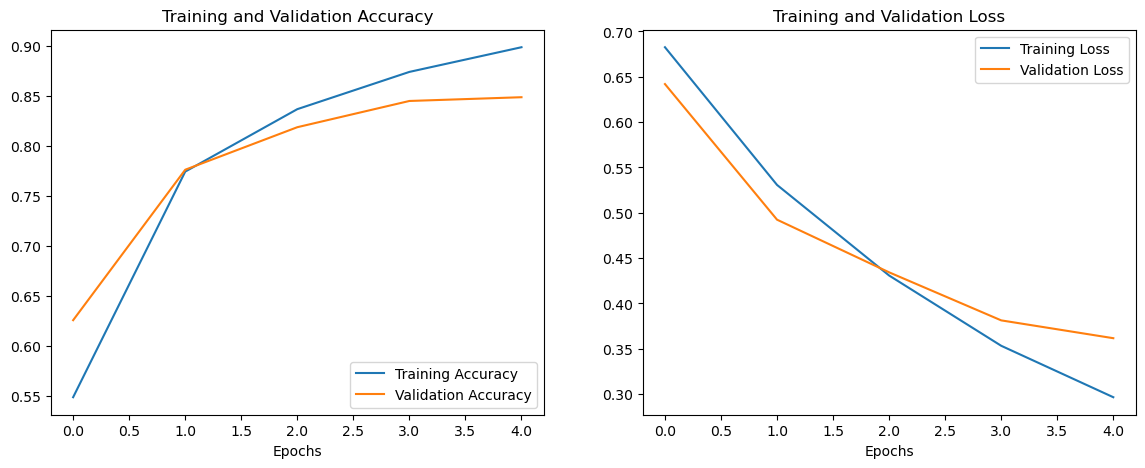

In [11]:
# plotting the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()